# Statistical Foundations II: Autocorrelation & ARCH Effects

**Day 6 Task**: Analyze autocorrelation in FX returns and test for volatility clustering

**Key Questions:**
1. Are FX returns serially correlated?
2. Is there evidence of ARCH effects (volatility clustering)?
3. What does this mean for strategy design?

**Tests:**
- ACF/PACF plots for returns
- Ljung-Box test for serial correlation
- ARCH test (Ljung-Box on squared returns)
- Volatility clustering visualization

In [1]:
# Setup
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
# Load FX data
data_dir = project_root / 'data' / 'raw'
pairs = ['EURUSD60', 'GBPUSD60', 'USDJPY60']

data = {}
returns_data = {}

for pair in pairs:
    filepath = data_dir / f'{pair}.csv'
    if filepath.exists():
        df = pd.read_csv(
            filepath,
            header=None,
            names=['date', 'time', 'open', 'high', 'low', 'close', 'volume']
        )
        
        # Parse datetime from date + time columns
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], utc=True)
        df.set_index('datetime', inplace=True)
        df.drop(columns=['date', 'time'], inplace=True)
        
        pair_name = pair.replace('60', '')
        data[pair_name] = df
        
        # Compute returns
        returns = np.log(df['close'] / df['close'].shift(1)).dropna()
        returns_data[pair_name] = returns
        
        print(f'✅ {pair}: {len(returns):,} returns')

print(f'\nLoaded {len(data)} pairs')

✅ EURUSD60: 2,047 returns
✅ GBPUSD60: 64,999 returns
✅ USDJPY60: 2,048 returns

Loaded 3 pairs


## 1. ACF/PACF Analysis

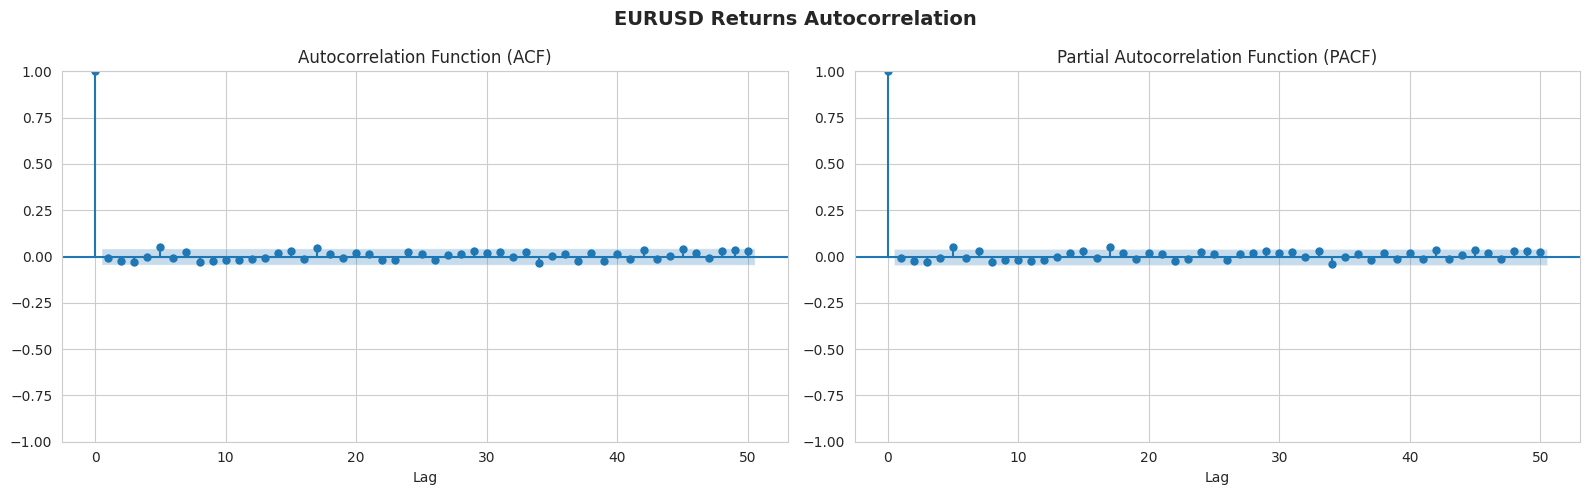

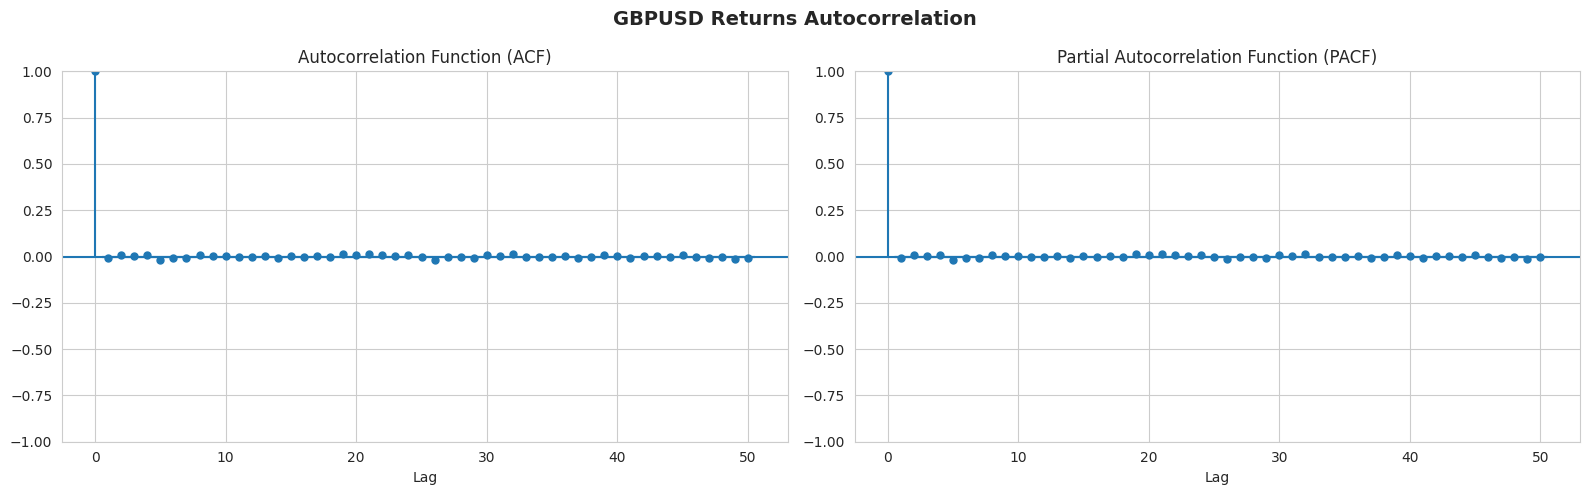

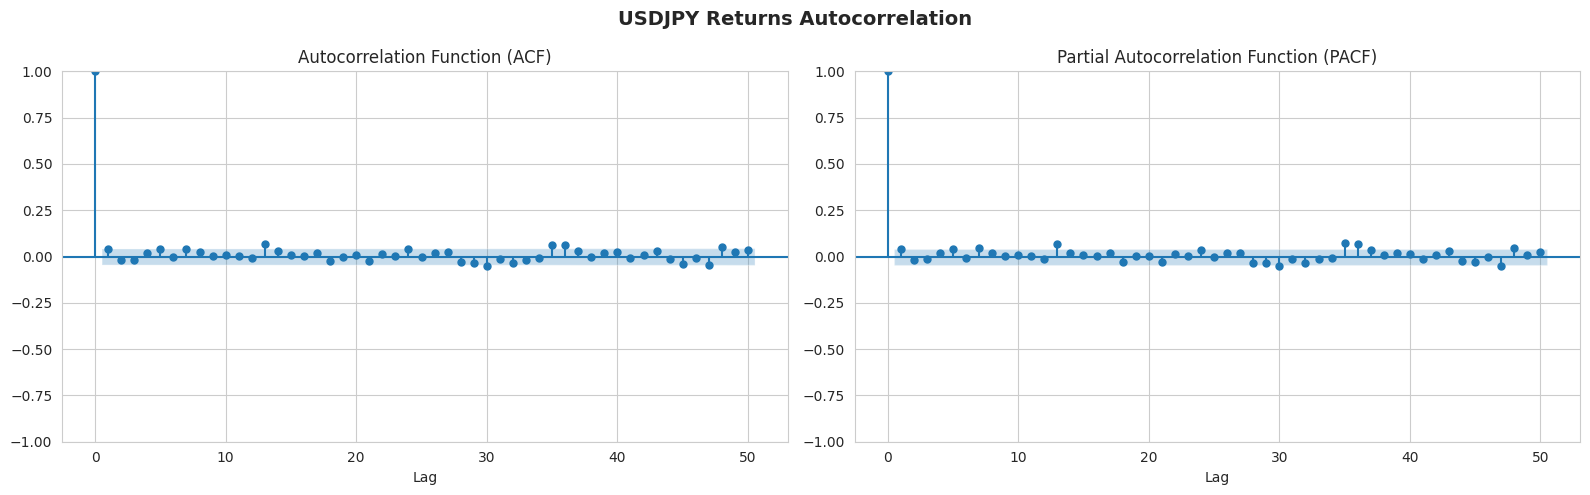

In [3]:
def plot_acf_pacf(returns, title, lags=50):
    """Plot ACF and PACF side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    plot_acf(returns, lags=lags, ax=axes[0])
    axes[0].set_title('Autocorrelation Function (ACF)')
    axes[0].set_xlabel('Lag')
    
    plot_pacf(returns, lags=lags, ax=axes[1])
    axes[1].set_title('Partial Autocorrelation Function (PACF)')
    axes[1].set_xlabel('Lag')
    
    plt.tight_layout()
    plt.show()

# Plot for each pair
for pair, returns in returns_data.items():
    plot_acf_pacf(returns, f'{pair} Returns Autocorrelation', lags=50)

## 2. Ljung-Box Test for Serial Correlation

**Null Hypothesis**: Returns are independently distributed (no serial correlation)

If p-value < 0.05 → Reject H0 → Serial correlation present

In [4]:
def ljungbox_test(returns, lags=20):
    """Run Ljung-Box test for serial correlation."""
    result = acorr_ljungbox(returns, lags=lags, return_df=True)
    
    # Check if any lag has p-value < 0.05
    significant_lags = result[result['lb_pvalue'] < 0.05]
    
    return result, len(significant_lags) > 0

# Test each pair
ljung_results = {}

for pair, returns in returns_data.items():
    result, has_correlation = ljungbox_test(returns, lags=20)
    ljung_results[pair] = (result, has_correlation)
    
    print(f"\n{'='*60}")
    print(f"Ljung-Box Test: {pair} Returns")
    print(f"{'='*60}")
    print(result.head(10))
    
    if has_correlation:
        print(f"\n⚠️  Serial correlation detected (p < 0.05 at some lags)")
    else:
        print(f"\n✅ No significant serial correlation")


Ljung-Box Test: EURUSD Returns
      lb_stat  lb_pvalue
1    0.223351   0.636499
2    1.678017   0.432139
3    3.551511   0.314143
4    3.591835   0.464053
5    9.525379   0.089856
6    9.722564   0.136832
7   10.985929   0.139234
8   12.876088   0.116185
9   13.836502   0.128261
10  14.428121   0.154344

✅ No significant serial correlation

Ljung-Box Test: GBPUSD Returns
      lb_stat     lb_pvalue
1    6.939463  8.431442e-03
2    9.438573  8.921542e-03
3    9.679837  2.149319e-02
4   15.377831  3.978432e-03
5   39.364166  2.005904e-07
6   44.517259  5.836337e-08
7   49.258251  2.019383e-08
8   55.200572  4.035848e-09
9   55.253563  1.089671e-08
10  56.405281  1.723514e-08

⚠️  Serial correlation detected (p < 0.05 at some lags)

Ljung-Box Test: USDJPY Returns
      lb_stat  lb_pvalue
1    3.853240   0.049650
2    4.539182   0.103354
3    5.104292   0.164318
4    5.748794   0.218710
5    9.147538   0.103322
6    9.172443   0.164110
7   12.848538   0.075886
8   14.044345   0.080617
9 

## 3. ARCH Effects Test (Volatility Clustering)

**Test**: Apply Ljung-Box to **squared returns**

**Interpretation**: If squared returns are autocorrelated → Volatility clustering (ARCH effects)

In [5]:
# Test squared returns for ARCH effects
arch_results = {}

for pair, returns in returns_data.items():
    squared_returns = returns ** 2
    result, has_arch = ljungbox_test(squared_returns, lags=20)
    arch_results[pair] = (result, has_arch)
    
    print(f"\n{'='*60}")
    print(f"ARCH Test: {pair} Squared Returns")
    print(f"{'='*60}")
    print(result.head(10))
    
    if has_arch:
        print(f"\n✅ ARCH effects detected → Volatility clustering present")
        print(f"   Implication: Use GARCH models or rolling volatility estimation")
    else:
        print(f"\n❌ No ARCH effects")


ARCH Test: EURUSD Squared Returns
      lb_stat     lb_pvalue
1   19.083266  1.251373e-05
2   20.622383  3.325878e-05
3   27.287734  5.123751e-06
4   30.903088  3.203954e-06
5   35.230965  1.353101e-06
6   35.260866  3.835885e-06
7   35.525691  8.906588e-06
8   45.463592  3.005514e-07
9   47.552137  3.096456e-07
10  47.556362  7.478142e-07

✅ ARCH effects detected → Volatility clustering present
   Implication: Use GARCH models or rolling volatility estimation

ARCH Test: GBPUSD Squared Returns
        lb_stat      lb_pvalue
1    386.781946   4.153928e-86
2    464.146843  1.628522e-101
3   3527.576681   0.000000e+00
4   3640.946107   0.000000e+00
5   4086.989496   0.000000e+00
6   4204.966171   0.000000e+00
7   4231.667534   0.000000e+00
8   4559.734848   0.000000e+00
9   4580.872614   0.000000e+00
10  4603.862232   0.000000e+00

✅ ARCH effects detected → Volatility clustering present
   Implication: Use GARCH models or rolling volatility estimation

ARCH Test: USDJPY Squared Returns


## 4. Visualize Volatility Clustering

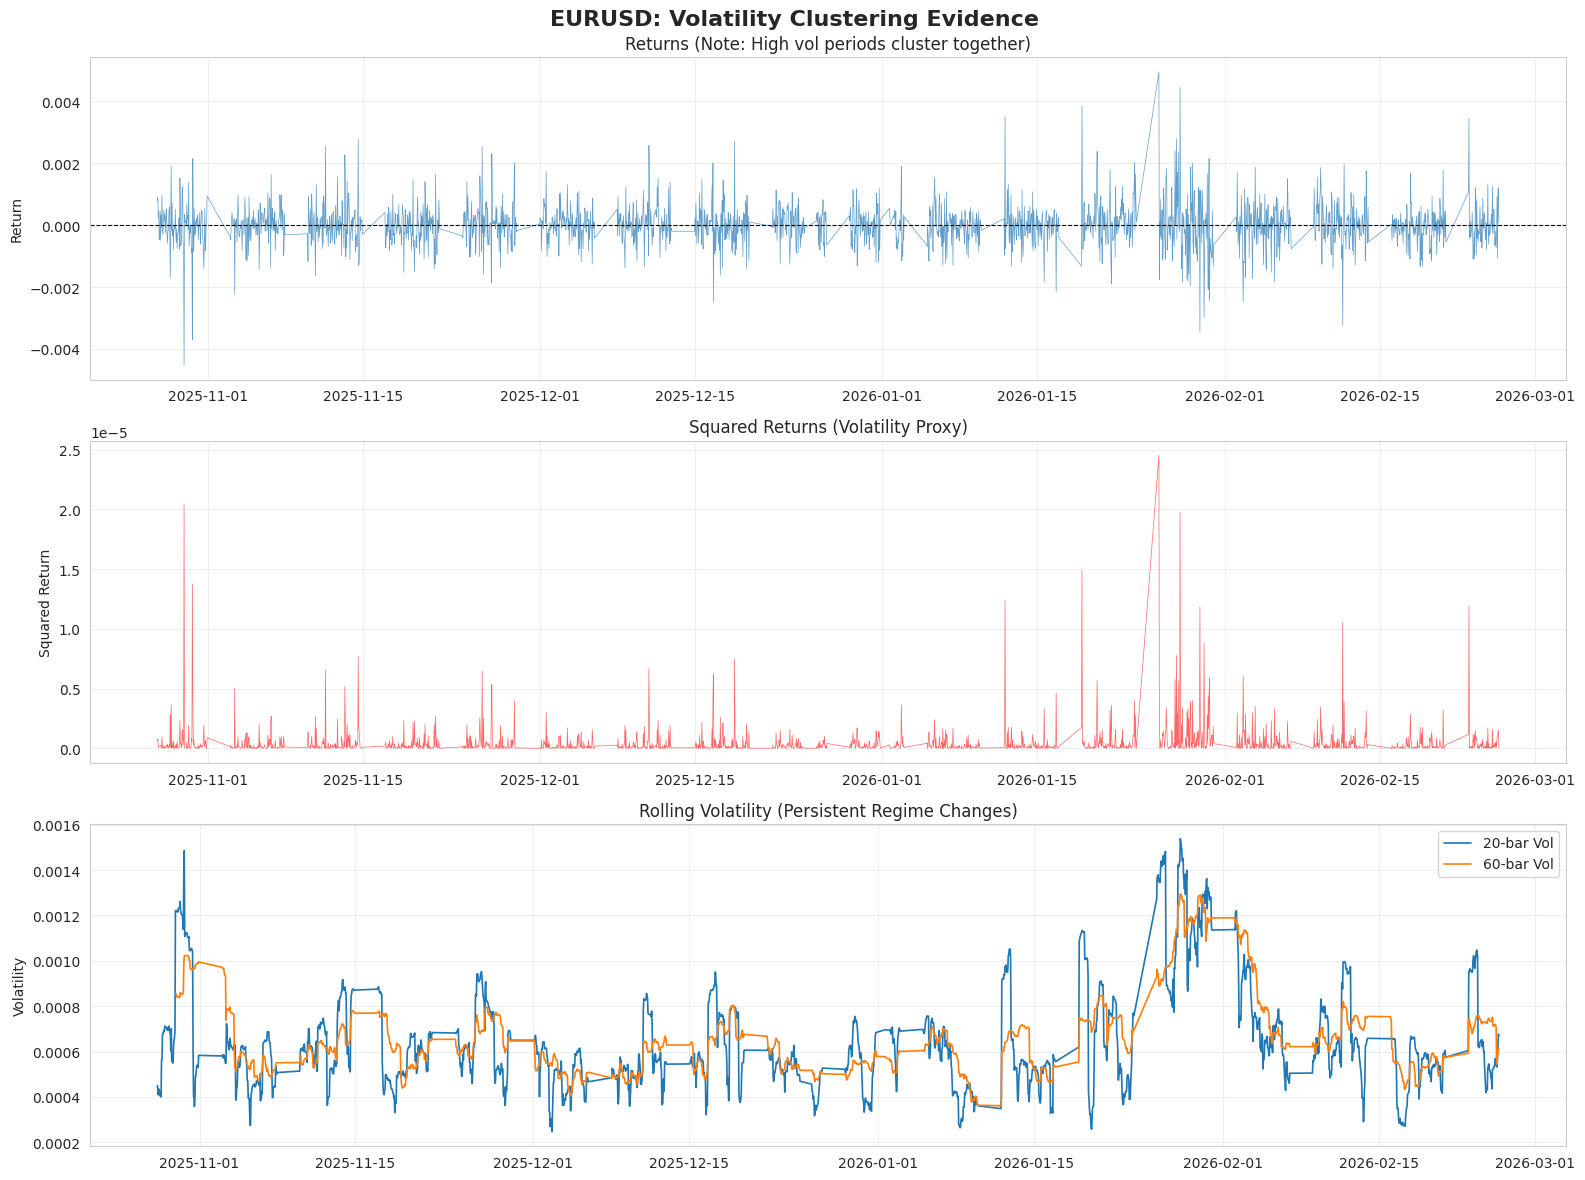

In [6]:
# Volatility clustering visualization for EURUSD
pair = 'EURUSD'
returns = returns_data[pair]

# Compute rolling volatility
rolling_vol_20 = returns.rolling(window=20).std()
rolling_vol_60 = returns.rolling(window=60).std()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle(f'{pair}: Volatility Clustering Evidence', fontsize=16, fontweight='bold')

# Returns
axes[0].plot(returns.index, returns, linewidth=0.5, alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Returns (Note: High vol periods cluster together)')
axes[0].set_ylabel('Return')
axes[0].grid(True, alpha=0.3)

# Squared returns (proxy for volatility)
axes[1].plot(returns.index, returns**2, linewidth=0.5, color='red', alpha=0.6)
axes[1].set_title('Squared Returns (Volatility Proxy)')
axes[1].set_ylabel('Squared Return')
axes[1].grid(True, alpha=0.3)

# Rolling volatility
axes[2].plot(rolling_vol_20.index, rolling_vol_20, label='20-bar Vol', linewidth=1.2)
axes[2].plot(rolling_vol_60.index, rolling_vol_60, label='60-bar Vol', linewidth=1.2)
axes[2].set_title('Rolling Volatility (Persistent Regime Changes)')
axes[2].set_ylabel('Volatility')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. ACF of Absolute and Squared Returns

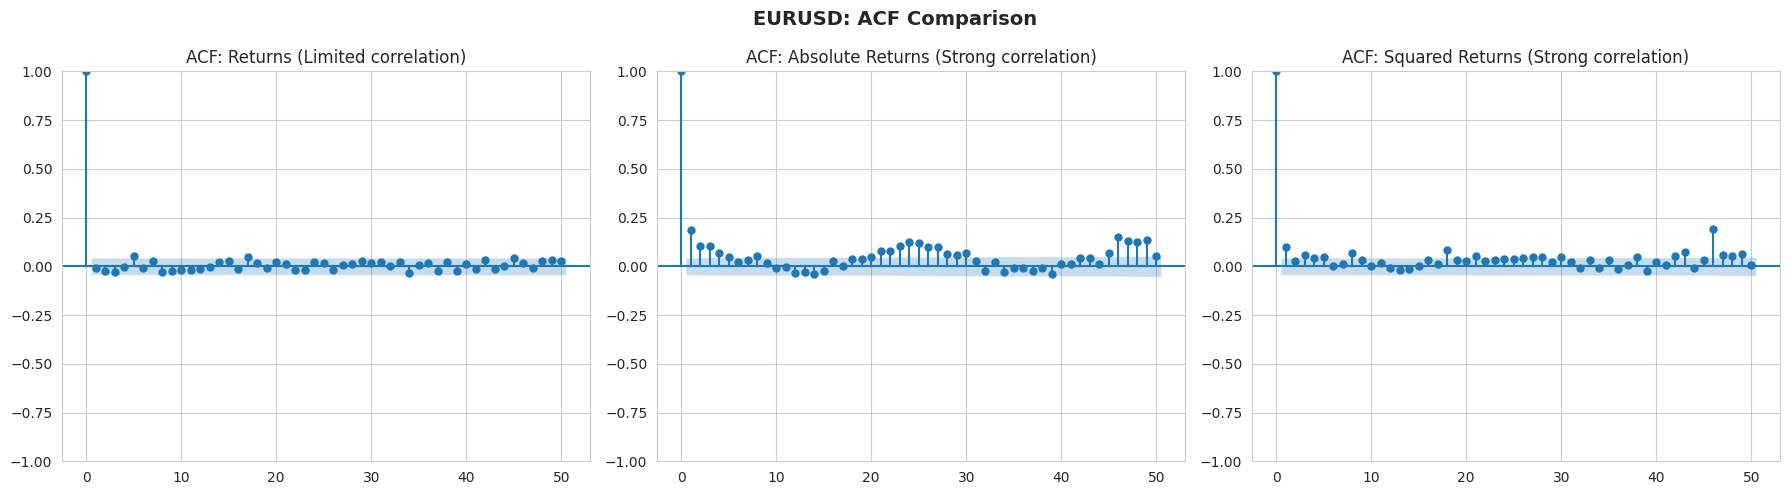


📊 Interpretation:
   - Returns: Low autocorrelation → Hard to predict direction
   - Absolute/Squared Returns: High autocorrelation → Volatility is predictable!
   - Implication: Focus strategies on volatility forecasting, not return forecasting


In [7]:
# Compare ACF for returns, absolute returns, and squared returns
pair = 'EURUSD'
returns = returns_data[pair]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{pair}: ACF Comparison', fontsize=14, fontweight='bold')

plot_acf(returns, lags=50, ax=axes[0])
axes[0].set_title('ACF: Returns (Limited correlation)')

plot_acf(np.abs(returns), lags=50, ax=axes[1])
axes[1].set_title('ACF: Absolute Returns (Strong correlation)')

plot_acf(returns**2, lags=50, ax=axes[2])
axes[2].set_title('ACF: Squared Returns (Strong correlation)')

plt.tight_layout()
plt.show()

print("\n📊 Interpretation:")
print("   - Returns: Low autocorrelation → Hard to predict direction")
print("   - Absolute/Squared Returns: High autocorrelation → Volatility is predictable!")
print("   - Implication: Focus strategies on volatility forecasting, not return forecasting")

## 6. Summary Table

In [8]:
# Create comprehensive summary
summary_data = []

for pair in returns_data.keys():
    _, has_serial_corr = ljung_results[pair]
    _, has_arch = arch_results[pair]
    
    summary_data.append({
        'Pair': pair,
        'Serial Correlation': '✅ Yes' if has_serial_corr else '❌ No',
        'ARCH Effects': '✅ Yes' if has_arch else '❌ No',
        'Volatility Clustering': '✅ Strong' if has_arch else '❌ Weak'
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("AUTOCORRELATION & ARCH EFFECTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


AUTOCORRELATION & ARCH EFFECTS SUMMARY
  Pair Serial Correlation ARCH Effects Volatility Clustering
EURUSD               ❌ No        ✅ Yes              ✅ Strong
GBPUSD              ✅ Yes        ✅ Yes              ✅ Strong
USDJPY              ✅ Yes        ✅ Yes              ✅ Strong


## Key Findings & Strategy Implications

### Expected Results:

1. **Returns have weak serial correlation**
   - Difficult to predict next return from past returns
   - Simple momentum may not work well
   - Need more sophisticated signal generation

2. **Strong ARCH effects (volatility clustering)** ✅
   - High volatility periods persist
   - Low volatility periods persist
   - Volatility is more predictable than returns!

### Design Implications:

```python
# ✅ GOOD: Volatility-based position sizing
current_vol = returns.rolling(20).std().iloc[-1]
target_vol = 0.15  # annualized
position_size = (target_vol / current_vol) * base_size

# ✅ GOOD: Regime detection based on volatility
regime = 'high_vol' if current_vol > threshold else 'low_vol'

# ❌ BAD: Ignoring volatility clustering
position_size = 1.0  # constant size regardless of vol
```

### Next Steps:
1. Implement GARCH model for vol forecasting
2. Use HMM for regime detection (high/low vol states)
3. Design vol-adjusted position sizing
4. Consider vol-targeting strategies

In [9]:
# Save report
report_dir = project_root / 'reports'
report_path = report_dir / 'autocorrelation_analysis.md'

with open(report_path, 'w') as f:
    f.write("# Autocorrelation & ARCH Effects Analysis\n\n")
    f.write("## Executive Summary\n\n")
    f.write("**Finding 1:** Returns show weak serial correlation - direction is hard to predict.\n\n")
    f.write("**Finding 2:** Strong ARCH effects detected - volatility clusters and is predictable.\n\n")
    f.write("**Implication:** Focus on volatility-based strategies and regime detection rather than return prediction.\n\n")
    f.write("## Test Results\n\n")
    f.write(summary_df.to_markdown(index=False))
    f.write("\n\n## Methodology\n\n")
    f.write("- **Ljung-Box Test**: Tests for serial correlation in returns\n")
    f.write("- **ARCH Test**: Ljung-Box applied to squared returns (tests for vol clustering)\n")
    f.write("- **ACF/PACF**: Visual inspection of correlation structure\n")
    f.write("\n## Recommendations\n\n")
    f.write("1. Implement GARCH models for volatility forecasting\n")
    f.write("2. Use HMM regime detection (high/low vol states)\n")
    f.write("3. Design vol-adjusted position sizing\n")
    f.write("4. Consider vol-targeting strategies\n")

print(f"\n✅ Report saved to: {report_path}")

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.